# Phase 9 — Executive Intelligence Platform

This phase converts the insurance digital twin into an executive decision system.

It integrates:
- pricing and frequency evidence from Phase 6
- SIU and fraud operating constraints from Phase 7
- capital stress, EP metrics, and governance from Phase 8
- Week 9 executive analytics, guarded narrative, retrieval-assisted Q&A, and Streamlit deployment

The aim is not to build another model.

The aim is to convert prior analytical layers into decision-ready portfolio intelligence.

In [1]:
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from phase9_core import (
    get_paths,
    load_inputs,
    prepare_portfolio,
    build_segment_view,
    governance_pass,
    build_snapshot,
    build_strategy,
    build_rag_documents,
    build_payload,
    save_payload,
    get_capital_metrics,
    rank_segments_for_decision,
    executive_decision_agent,
    board_commentary_agent,
    retrieve_context,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
paths = get_paths()
bundle = load_inputs(paths)

claims = bundle["claims"]
policies = bundle["policies"]
policyholders = bundle["policyholders"]
macro = bundle["macro"]
rel_prod = bundle["rel_prod"]
rel_channel = bundle["rel_channel"]
siu_capacity = bundle["siu_capacity"]
siu_cost = bundle["siu_cost"]
siu_threshold = bundle["siu_threshold"]
scenario_summary = bundle["scenario_summary"]
loss_distribution = bundle["loss_distribution"]
phase6_metrics = bundle["phase6_metrics"]
ep_metrics = bundle["ep_metrics"]
governance = bundle["governance"]
phase8_exec_report = bundle["phase8_exec_report"]

print("Claims:", claims.shape)
print("Policies:", policies.shape)
print("Policyholders:", policyholders.shape)
print("Macro:", macro.shape)

Claims: (148907, 12)
Policies: (120000, 11)
Policyholders: (80000, 8)
Macro: (84, 5)


## Portfolio Scale

This portfolio is large enough to support executive-level analytics.

The available portfolio contains:
- 120,000 policies
- 148,907 claims
- 80,000 policyholders
- 84 macro rows

It also includes prior actuarial, fraud, and capital outputs required for a decision layer.

In [3]:
prepared = prepare_portfolio(claims, policies, rel_prod, rel_channel)

claims = prepared["claims"]
policies = prepared["policies"]
merged = prepared["merged"]
paid_col = prepared["paid_col"]
reserve_col = prepared["reserve_col"]
fraud_col = prepared["fraud_col"]
claim_id_col = prepared["claim_id_col"]
product_col = prepared["product_col"]
channel_col = prepared["channel_col"]
premium_basis = prepared["premium_basis"]

prepared.keys()

dict_keys(['claims', 'policies', 'merged', 'paid_col', 'reserve_col', 'fraud_col', 'claim_id_col', 'product_col', 'channel_col', 'premium_basis'])

In [4]:
inflation_shock = float(scenario_summary["inflation_shock"].iloc[0]) if "inflation_shock" in scenario_summary.columns else 0.12
frequency_shock = float(scenario_summary["frequency_shock"].iloc[0]) if "frequency_shock" in scenario_summary.columns else 0.08
fraud_multiplier = float(scenario_summary["fraud_multiplier"].iloc[0]) if "fraud_multiplier" in scenario_summary.columns else 1.25

segment = build_segment_view(
    policies=policies,
    merged=merged,
    product_col=product_col,
    channel_col=channel_col,
    claim_id_col=claim_id_col,
    fraud_multiplier=fraud_multiplier,
    inflation_shock=inflation_shock,
    frequency_shock=frequency_shock,
    premium_basis=premium_basis,
)

pressure_label = segment["pressure_label"].iloc[0]
segment.head(10)

,product_type,channel,policies,earned_premium,expected_frequency,freq_stressed,stressed_loss,mean_severity,actual_claim_count,actual_incurred,actual_avg_severity,loss_share,capital_share_proxy,stressed_loss_bn,loss_ratio_stressed,pressure_metric,pressure_label
0,home,broker,13213,"180,201,216.3235","1,037.8720","1,120.9017","19,028,693.2684","15,157.3546",9539,"144,586,005.3463","15,157.3546",0.1932,0.1932,0.0190,0.1056,0.1056,loss_ratio_stressed
1,motor,broker,29666,"159,939,455.2652","4,004.2972","4,324.6409","18,623,698.1613","3,076.0106",36609,"112,609,673.4536","3,076.0106",0.1891,0.1891,0.0186,0.1164,0.1164,loss_ratio_stressed
2,health,broker,7713,"112,051,389.3847","2,075.4291","2,241.4635","13,439,792.3007","5,353.5624",18648,"99,833,232.2821","5,353.5624",0.1364,0.1364,0.0134,0.1199,0.1199,loss_ratio_stressed
3,motor,direct,16368,"88,275,331.7588","2,079.0630","2,245.3880","9,895,145.0616","3,147.7681",19856,"62,502,083.6358","3,147.7681",0.1005,0.1005,0.0099,0.1121,0.1121,loss_ratio_stressed
4,home,direct,7137,"97,421,933.9738",527.8363,570.0632,"9,857,391.3985","15,439.0649",4645,"71,714,456.6389","15,439.0649",0.1001,0.1001,0.0099,0.1012,0.1012,loss_ratio_stressed
5,health,direct,4365,"63,763,734.2802","1,105.1450","1,193.5566","7,496,590.5847","5,607.9320",10485,"58,799,166.7838","5,607.9320",0.0761,0.0761,0.0075,0.1176,0.1176,loss_ratio_stressed
6,home,aggregator,3628,"49,178,768.1448",308.3365,333.0035,"5,715,829.6932","15,325.4239",2866,"43,922,664.9012","15,325.4239",0.0580,0.0580,0.0057,0.1162,0.1162,loss_ratio_stressed
7,motor,aggregator,8124,"43,730,024.6014","1,188.2007","1,283.2567","5,587,894.1636","3,110.3309",11156,"34,698,851.2359","3,110.3309",0.0567,0.0567,0.0056,0.1278,0.1278,loss_ratio_stressed
8,health,aggregator,2244,"32,576,756.3359",654.5567,706.9212,"4,262,456.9961","5,383.5774",5531,"29,776,566.4224","5,383.5774",0.0433,0.0433,0.0043,0.1308,0.1308,loss_ratio_stressed
9,warranty,broker,9902,"28,807,572.2672","1,489.7905","1,608.9738","1,587,749.9944",881.0796,13798,"12,157,135.8014",881.0796,0.0161,0.0161,0.0016,0.0551,0.0551,loss_ratio_stressed


## Executive Snapshot

This first-page view captures:
- portfolio scale
- paid and reserve position
- average severity
- fraud intensity

In [5]:
snapshot = build_snapshot(claims, policies, paid_col, reserve_col, fraud_col)
pd.DataFrame(snapshot.items(), columns=["metric", "value"])

,metric,value
0,policies,"120,000.0000"
1,claims,"148,907.0000"
2,paid,"659,890,899.5093"
3,reserve,"32,238,859.6308"
4,avg_severity,"4,663.6144"
5,fraud_rate,0.0760


In [6]:
capital_metrics = get_capital_metrics(scenario_summary, ep_metrics)

capital_required = capital_metrics["capital_required"]
capital_available = capital_metrics["capital_available"]
solvency_ratio = capital_metrics["solvency_ratio"]

capital_required, capital_available, solvency_ratio

(1110431945.718766, 50000000.0, 0.04502752302180549)

In [7]:
governance_ok = governance_pass(governance)
strategy_df = build_strategy(segment, premium_basis)

assert len(strategy_df) > 0, "Strategy generation failed"

governance_ok, strategy_df.head()

(True,
   product_type     channel                         action  \
 0       health  aggregator  Increase pricing aggressively   
 1        motor  aggregator    Increase pricing moderately   
 2       health      broker    Increase pricing moderately   
 3       health      direct    Increase pricing moderately   
 4        motor      broker    Increase pricing moderately   
 
    recommended_rate_change_pct  retention_factor  metric_before  metric_after  \
 0                       0.0800            0.9520         0.1308        0.1273   
 1                       0.0500            0.9400         0.1278        0.1295   
 2                       0.0500            0.9700         0.1199        0.1178   
 3                       0.0500            0.9700         0.1176        0.1154   
 4                       0.0500            0.9400         0.1164        0.1180   
 
    capital_share_proxy                                          rationale  
 0               0.0433  Stressed loss ratio mat

## Portfolio Concentration

This section identifies where stressed loss is concentrated across product and channel.

In [8]:
fig = px.treemap(
    segment,
    path=[px.Constant("Portfolio"), product_col, channel_col],
    values="stressed_loss",
    color="pressure_metric",
    color_continuous_scale="Reds",
    title="Portfolio Concentration Treemap — Stressed Loss"
)
fig.show()

In [9]:
fig = px.bar(
    segment.head(12),
    x=product_col,
    y="stressed_loss_bn",
    color=channel_col,
    barmode="group",
    hover_data=["policies", "loss_share", "pressure_metric"],
    title="Top Segment Risk Drivers — Stressed Loss (£bn)"
)
fig.update_layout(height=520)
fig.show()

## Frequency–Severity–Loss Surface

This view separates large segments caused by frequency from those driven by severity.

In [10]:
fig = px.scatter_3d(
    segment,
    x="freq_stressed",
    y="mean_severity",
    z="stressed_loss",
    color=product_col,
    size="capital_share_proxy",
    hover_data=[channel_col, "policies", "pressure_metric"],
    title="3D Risk Surface — Frequency vs Severity vs Stressed Loss"
)
fig.show()

## Pressure Diagnostics

If actual premium is available, this is a stressed loss-ratio view.
If not, it becomes a relative pressure indicator.

In [11]:
fig = px.scatter(
    segment,
    x="policies",
    y="mean_severity",
    size="stressed_loss",
    color="pressure_metric",
    hover_data=[product_col, channel_col, "loss_share"],
    title=f"Pressure Map — {pressure_label}"
)
fig.update_layout(height=540)
fig.show()

## Tail Risk and Capital Interpretation

In [12]:
ep_metrics

{'mean_loss_bn': 0.7788968164602842,
 'loss_1_in_100_bn': 1.078589067948964,
 'loss_1_in_200_bn': 1.110431945718766,
 'tvar_99_bn': 1.1222984829990243,
 'max_loss_bn': 1.2159240935570723,
 'simulation_count': 5000}

In [13]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Portfolio Loss Distribution",
        "Inflation Sensitivity",
        "Portfolio Risk Metrics",
        "Capital Adequacy"
    )
)

fig.add_trace(
    go.Histogram(x=loss_distribution["portfolio_loss"], nbinsx=50, name="Loss Distribution"),
    row=1, col=1
)

inflation_grid = np.linspace(0, 0.25, 6)
base_mean = ep_metrics["mean_loss_bn"] * 1e9
inflation_loss = base_mean * (1 + inflation_grid)
fig.add_trace(
    go.Scatter(x=inflation_grid, y=inflation_loss / 1e9, mode="lines+markers", name="Inflation Sensitivity"),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=["Expected Loss", "99.5% Tail"],
        y=[ep_metrics["mean_loss_bn"], ep_metrics["loss_1_in_200_bn"]],
        name="Risk Metrics"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Bar(
        x=["Capital Available", "Capital Required"],
        y=[capital_available / 1e9, capital_required / 1e9],
        name="Capital Adequacy"
    ),
    row=2, col=2
)

fig.update_layout(height=900, title="Capital and Tail Risk Dashboard", showlegend=False)
fig.show()

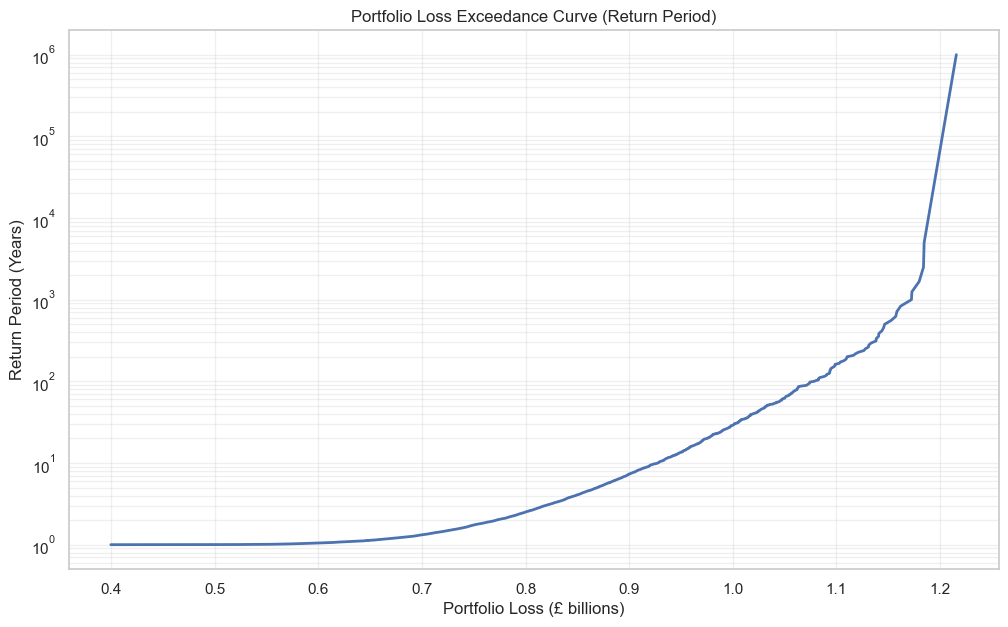

In [14]:
loss_sorted = np.sort(loss_distribution["portfolio_loss"].values)
n = len(loss_sorted)
return_period = 1 / np.maximum(1 - (np.arange(1, n + 1) / n), 1e-6)

plt.figure(figsize=(12, 7))
plt.plot(loss_sorted / 1e9, return_period, linewidth=2)
plt.yscale("log")
plt.xlabel("Portfolio Loss (£ billions)")
plt.ylabel("Return Period (Years)")
plt.title("Portfolio Loss Exceedance Curve (Return Period)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [15]:
fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=solvency_ratio,
    title={"text": "Solvency Ratio"},
    gauge={
        "axis": {"range": [0, 2.5]},   # 🔥 FIX
        "bar": {"color": "darkred" if solvency_ratio < 1 else "orange"},
        "steps": [
            {"range": [0, 1.0], "color": "#ff4d4d"},   # red (under-capitalised)
            {"range": [1.0, 1.5], "color": "#ffcc00"}, # amber
            {"range": [1.5, 2.5], "color": "#66cc66"}  # green
        ],
        "threshold": {
            "line": {"color": "black", "width": 4},
            "value": 1.0   # regulatory line
        }
    }
))

fig.update_layout(height=400, title="Capital Adequacy Gauge")
fig.show()

## Fraud and SIU Operating View

In [16]:
display(siu_capacity.head())
display(siu_cost.head())
display(siu_threshold.head())

,review_pct,claims_reviewed,fraud_rate_in_reviewed
0,0.0100,124,0.2581
1,0.0200,248,0.2500
2,0.0500,621,0.2045
3,0.1000,1242,0.1908


,review_pct,expected_capture,review_cost,net_value
0,0.0100,"264,748.6000","31,000.0000","233,748.6000"
1,0.0200,"418,234.1529","62,000.0000","356,234.1529"
2,0.0500,"725,030.9338","155,250.0000","569,780.9338"
3,0.1000,"1,256,169.6238","310,500.0000","945,669.6238"


,optimal_index,optimal_score_threshold,max_net_value
0,4512,0.0693,"2,581,907.6306"


In [17]:
if fraud_col:

    fraud_segment = (
        merged.groupby([product_col, channel_col], dropna=False)
        .agg(
            actual_claim_count=(claim_id_col, "count"),
            fraud_rate=(fraud_col, "mean"),
            avg_severity=("severity", "mean"),
            incurred=("severity", "sum"),
        )
        .reset_index()
    )

    # ---------------------------
    # SIU ECONOMIC VALUE LINK
    # ---------------------------
    # expected fraud loss
    fraud_segment["fraud_loss_est"] = (
        fraud_segment["fraud_rate"] * fraud_segment["incurred"]
    )

    # assume SIU recovery efficiency (can calibrate later)
    SIU_RECOVERY_RATE = 0.35

    fraud_segment["recoverable_amount"] = (
        fraud_segment["fraud_loss_est"] * SIU_RECOVERY_RATE
    )

    # ---------------------------
    # LINK TO CAPITAL (CRITICAL)
    # ---------------------------
    # how much capital relief each segment gives
    fraud_segment["capital_relief_proxy"] = (
        fraud_segment["recoverable_amount"] / fraud_segment["incurred"].sum()
    )

    fraud_segment = fraud_segment.sort_values(
        ["capital_relief_proxy", "fraud_rate"],
        ascending=False
    )

    display(fraud_segment.head(10))

else:
    print("No fraud flag available in claims data.")

,product_type,channel,actual_claim_count,fraud_rate,avg_severity,incurred,fraud_loss_est,recoverable_amount,capital_relief_proxy
7,home,broker,9539,0.0759,"15,157.3546","144,586,005.3463","10,973,924.7165","3,840,873.6508",0.0055
10,motor,broker,36609,0.0763,"3,076.0106","112,609,673.4536","8,597,449.7337","3,009,107.4068",0.0043
4,health,broker,18648,0.0731,"5,353.5624","99,833,232.2821","7,302,259.1609","2,555,790.7063",0.0037
8,home,direct,4645,0.0790,"15,439.0649","71,714,456.6389","5,666,136.8324","1,983,147.8913",0.0029
11,motor,direct,19856,0.0755,"3,147.7681","62,502,083.6358","4,721,652.1683","1,652,578.2589",0.0024
5,health,direct,10485,0.0756,"5,607.9320","58,799,166.7838","4,447,090.0581","1,556,481.5203",0.0022
6,home,aggregator,2866,0.0883,"15,325.4239","43,922,664.9012","3,877,332.2470","1,357,066.2865",0.0020
9,motor,aggregator,11156,0.0809,"3,110.3309","34,698,851.2359","2,808,628.7797","983,020.0729",0.0014
3,health,aggregator,5531,0.0749,"5,383.5774","29,776,566.4224","2,228,801.0304","780,080.3606",0.0011
13,warranty,broker,13798,0.0731,881.0796,"12,157,135.8014","888,128.1989","310,844.8696",0.0004


In [18]:
if fraud_col:

    fig = px.scatter(
        fraud_segment,
        x="fraud_rate",
        y="avg_severity",
        size="recoverable_amount",   # 🔥 changed
        color="capital_relief_proxy", # 🔥 critical upgrade
        hover_data=[
            product_col,
            channel_col,
            "actual_claim_count",
            "recoverable_amount",
            "capital_relief_proxy"
        ],
        title="Fraud Pressure vs Capital Relief Opportunity"
    )

    fig.update_layout(height=550)

    fig.show()

In [19]:
# ==============================
# SIU → CAPITAL IMPACT SUMMARY (FIXED)
# ==============================

total_recoverable = fraud_segment["recoverable_amount"].sum()
total_loss = fraud_segment["incurred"].sum()

base_scr = capital_required

# ------------------------------
# TAIL-ADJUSTED IMPACT (CRITICAL FIX)
# ------------------------------
TAIL_MULTIPLIER = 2.0   # fraud concentrated in tail
MAX_TAIL_REDUCTION = 0.5  # cap realism

tail_impact = min(
    MAX_TAIL_REDUCTION,
    (total_recoverable / total_loss) * TAIL_MULTIPLIER
)

adjusted_scr = base_scr * (1 - tail_impact)

# ------------------------------
# NEW SOLVENCY
# ------------------------------
adjusted_solvency = capital_available / adjusted_scr

# ------------------------------
# OUTPUT
# ------------------------------
print("\nSIU IMPACT ON CAPITAL (TAIL-ADJUSTED)\n")

print(f"Recoverable fraud amount: {total_recoverable:,.0f}")
print(f"Total portfolio loss: {total_loss:,.0f}")
print(f"Tail impact applied: {tail_impact:.4f}")

print("\n--- CAPITAL ---")
print(f"Original SCR: {base_scr:,.0f}")
print(f"Adjusted SCR: {adjusted_scr:,.0f}")

print("\n--- SOLVENCY ---")
print(f"Solvency before: {solvency_ratio:.4f}")
print(f"Solvency after SIU: {adjusted_solvency:.4f}")


SIU IMPACT ON CAPITAL (TAIL-ADJUSTED)

Recoverable fraud amount: 18,670,480
Total portfolio loss: 694,444,834
Tail impact applied: 0.0538

--- CAPITAL ---
Original SCR: 1,110,431,946
Adjusted SCR: 1,050,722,963

--- SOLVENCY ---
Solvency before: 0.0450
Solvency after SIU: 0.0476


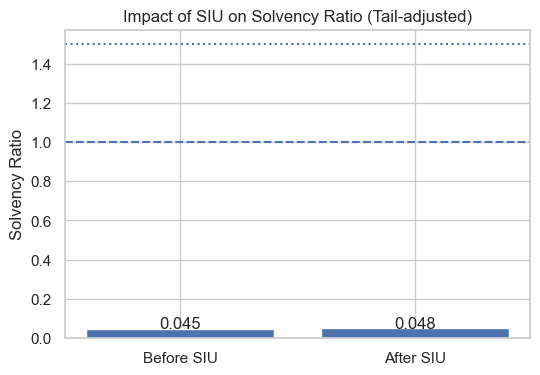

In [20]:
import matplotlib.pyplot as plt

values = [solvency_ratio, adjusted_solvency]

plt.figure(figsize=(6,4))
plt.bar(["Before SIU", "After SIU"], values)

# regulatory lines
plt.axhline(1.0, linestyle="--")
plt.axhline(1.5, linestyle=":")

# labels
for i, v in enumerate(values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.title("Impact of SIU on Solvency Ratio (Tail-adjusted)")
plt.ylabel("Solvency Ratio")

plt.show()

## Macro Overlay — Portfolio Sensitivity

This section evaluates how macroeconomic conditions translate into portfolio risk.

Rather than visualising macro variables in isolation, the analysis quantifies:

- current macro state (inflation, repair costs, unemployment)
- portfolio sensitivity to inflation shocks
- second-order impacts on frequency and fraud

The objective is to understand how external conditions propagate into loss and capital pressure.

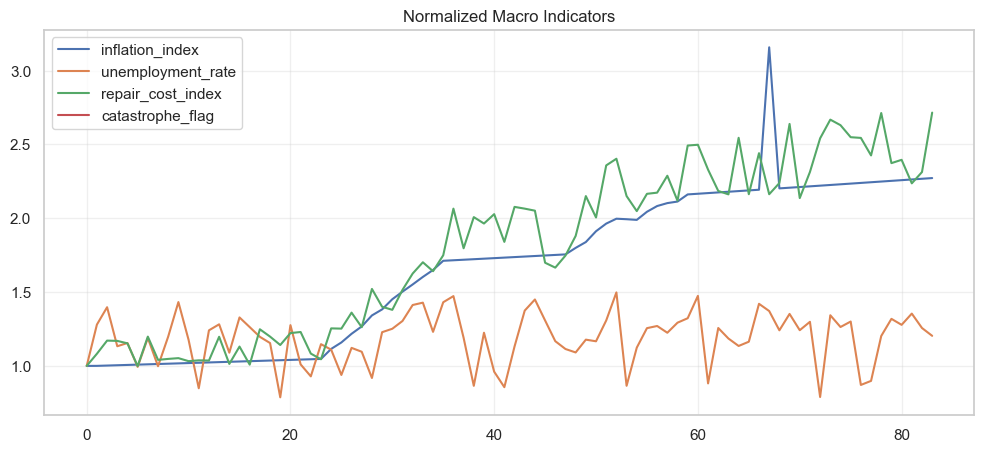

In [21]:
# --- MACRO CLEANING & NORMALISATION ---

macro_num = macro.select_dtypes(include=[np.number]).copy()

# winsorize (remove extreme outliers)
for col in macro_num.columns:
    upper = macro_num[col].quantile(0.99)
    lower = macro_num[col].quantile(0.01)
    macro_num[col] = macro_num[col].clip(lower, upper)

# normalize (base = first row)
macro_norm = macro_num / macro_num.iloc[0]

# plot
plt.figure(figsize=(12, 5))
for c in macro_norm.columns[:4]:
    plt.plot(macro_norm[c], label=c)

plt.title("Normalized Macro Indicators")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# --- MACRO SUMMARY ---

macro_cols = macro.select_dtypes(include=[np.number]).columns.tolist()
macro_summary = macro[macro_cols].mean()

print("\nMacro Summary (Average State):")
for col in macro_cols:
    print(f"{col}: {macro_summary[col]:.4f}")


Macro Summary (Average State):
inflation_index: 1.7310
unemployment_rate: 0.0582
repair_cost_index: 1.7190
catastrophe_flag: 0.0119


In [23]:
# --- MACRO IMPACT ON PORTFOLIO ---

print("\nInflation Sensitivity (Severity + Frequency + Fraud):")

# recompute base using SAME logic as simulation
base_df = segment.copy()

base_sev = base_df["mean_severity"]
base_freq = base_df["expected_frequency"]

base_fraud = np.where(
    base_df["product_type"].str.lower() == "motor",
    1.0,
    1.0
)

base_loss = (base_sev * base_freq * base_fraud).sum()

results = []

for shock in [0.0, 0.05, 0.1, 0.2]:
    stressed = segment.copy()

    # severity impact
    sev = stressed["mean_severity"] * (1 + shock)

    # frequency impact (secondary effect)
    freq = stressed["expected_frequency"] * (1 + shock * 0.3)

    # fraud impact (motor only)
    fraud_adj = np.where(
        stressed["product_type"].str.lower() == "motor",
        1 + shock * 0.2,
        1.0
    )

    stressed["loss"] = sev * freq * fraud_adj

    total_loss = stressed["loss"].sum()
    uplift = (total_loss - base_loss) / base_loss

    results.append({
        "inflation_shock": shock,
        "loss": total_loss,
        "uplift_pct": uplift
    })

    print(f"+{shock*100:.0f}% inflation → {total_loss:,.0f} ({uplift*100:.2f}% uplift)")


Inflation Sensitivity (Severity + Frequency + Fraud):
+0% inflation → 75,789,367 (0.00% uplift)
+5% inflation → 81,012,923 (6.89% uplift)
+10% inflation → 86,380,502 (13.97% uplift)
+20% inflation → 97,551,793 (28.71% uplift)


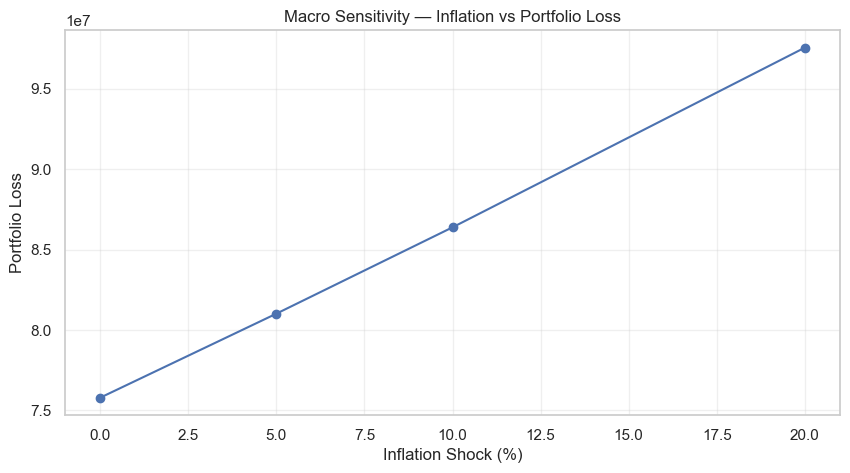

In [24]:
# --- PLOT SENSITIVITY CURVE ---

sens_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(sens_df["inflation_shock"] * 100, sens_df["loss"], marker="o")
plt.xlabel("Inflation Shock (%)")
plt.ylabel("Portfolio Loss")
plt.title("Macro Sensitivity — Inflation vs Portfolio Loss")
plt.grid(True, alpha=0.3)
plt.show()

### Macro Interpretation

The portfolio exhibits strong sensitivity to inflation-driven severity.

- Loss increases accelerate with inflation, indicating compounding effects from frequency and fraud
- Repair cost index closely tracks inflation, reinforcing severity as the primary driver
- Secondary amplification arises from behavioural effects and fraud sensitivity

This suggests the portfolio is exposed to inflation-driven convex risk and requires proactive pricing and underwriting adjustments under sustained macro stress.

## Macro Stress Transmission — Solvency and EP Curve

This section extends the macro overlay into capital interpretation.

It answers two questions:

- how inflation shocks shift expected and tail portfolio loss
- how those shifts affect solvency adequacy

The approach is deliberately transparent:
- severity responds directly to inflation
- frequency responds secondarily
- motor business receives an additional fraud-sensitive amplification
- the existing loss distribution is rescaled to approximate EP-curve movement under macro stress

In [25]:
# --- MACRO -> SOLVENCY & EP CURVE ENGINE ---

base_segment_loss = segment["stressed_loss"].sum()

# baseline EP metrics from Phase 8
base_mean_loss = ep_metrics["mean_loss_bn"] * 1e9
base_p95 = loss_distribution["portfolio_loss"].quantile(0.95)
base_p995 = ep_metrics["loss_1_in_200_bn"] * 1e9
base_tvar99 = ep_metrics["tvar_99_bn"] * 1e9

macro_scenarios = [0.00, 0.05, 0.10, 0.20]
macro_results = []

for shock in macro_scenarios:
    stressed = segment.copy()

    # severity impact
    sev_factor = 1 + shock

    # frequency impact
    freq_factor = 1 + shock * 0.30

    # fraud amplification, concentrated in motor
    fraud_factor = np.where(
        stressed["product_type"].str.lower() == "motor",
        1 + shock * 0.20,
        1.0
    )

    stressed["macro_stressed_loss"] = (
        stressed["mean_severity"]
        * sev_factor
        * stressed["expected_frequency"]
        * freq_factor
        * fraud_factor
    )

    macro_total_loss = stressed["macro_stressed_loss"].sum()

    # scale factor relative to current stressed portfolio
    scale_factor = macro_total_loss / base_segment_loss if base_segment_loss > 0 else 1.0

    # approximate shifted EP distribution
    shifted_losses = loss_distribution["portfolio_loss"] * scale_factor

    mean_loss = shifted_losses.mean()
    p95_loss = shifted_losses.quantile(0.95)
    p995_loss = shifted_losses.quantile(0.995)
    tvar99_loss = shifted_losses[shifted_losses >= shifted_losses.quantile(0.99)].mean()

    solvency_ratio_macro = capital_available / p995_loss if p995_loss > 0 else np.nan

    macro_results.append({
        "inflation_shock": shock,
        "scale_factor": scale_factor,
        "portfolio_loss": macro_total_loss,
        "mean_loss": mean_loss,
        "p95_loss": p95_loss,
        "p995_loss": p995_loss,
        "tvar99_loss": tvar99_loss,
        "solvency_ratio": solvency_ratio_macro,
    })

macro_results_df = pd.DataFrame(macro_results)
macro_results_df

,inflation_shock,scale_factor,portfolio_loss,mean_loss,p95_loss,p995_loss,tvar99_loss,solvency_ratio
0,0.0000,0.7695,"75,789,366.6076","599,333,955.5596","750,303,035.2692","854,438,683.4598","863,569,570.3458",0.0585
1,0.0500,0.8225,"81,012,922.5901","640,641,260.3867","802,015,433.5124","913,328,320.5750","923,088,526.5984",0.0547
2,0.1000,0.8770,"86,380,502.2799","683,087,488.8119","855,153,644.2341","973,841,660.7538","984,248,537.4804",0.0513
3,0.2000,0.9904,"97,551,793.1067","771,428,825.0661","965,747,699.7125","1,099,785,225.8463","1,111,537,987.8531",0.0455


In [26]:
macro_exec = macro_results_df.copy()

for col in ["portfolio_loss", "mean_loss", "p95_loss", "p995_loss", "tvar99_loss"]:
    macro_exec[col] = macro_exec[col] / 1e9

macro_exec["inflation_shock_pct"] = macro_exec["inflation_shock"] * 100
macro_exec = macro_exec[[
    "inflation_shock_pct",
    "portfolio_loss",
    "mean_loss",
    "p95_loss",
    "p995_loss",
    "tvar99_loss",
    "solvency_ratio",
]]

macro_exec.columns = [
    "Inflation Shock (%)",
    "Portfolio Loss (£bn)",
    "Mean Loss (£bn)",
    "P95 Loss (£bn)",
    "P99.5 Loss (£bn)",
    "TVaR99 (£bn)",
    "Solvency Ratio",
]

macro_exec

,Inflation Shock (%),Portfolio Loss (£bn),Mean Loss (£bn),P95 Loss (£bn),P99.5 Loss (£bn),TVaR99 (£bn),Solvency Ratio
0,0.0000,0.0758,0.5993,0.7503,0.8544,0.8636,0.0585
1,5.0000,0.0810,0.6406,0.8020,0.9133,0.9231,0.0547
2,10.0000,0.0864,0.6831,0.8552,0.9738,0.9842,0.0513
3,20.0000,0.0976,0.7714,0.9657,1.0998,1.1115,0.0455


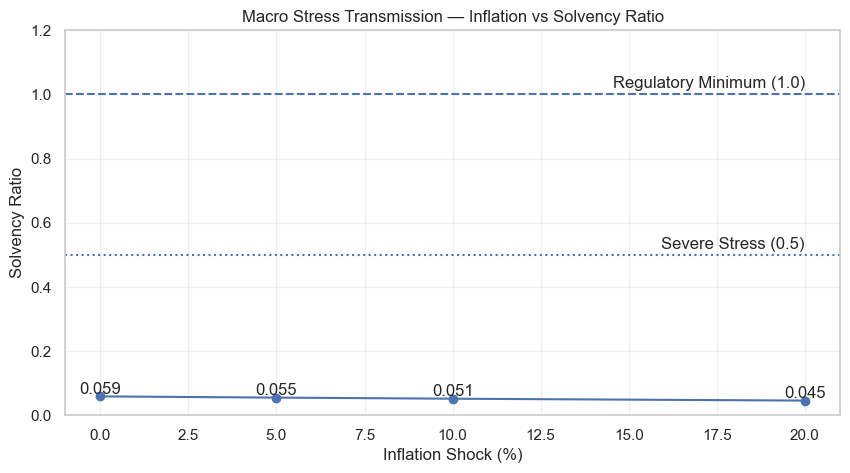

In [27]:
plt.figure(figsize=(10, 5))

x = macro_results_df["inflation_shock"] * 100
y = macro_results_df["solvency_ratio"]

plt.plot(x, y, marker="o")

# --- REGULATORY ZONES ---
plt.axhline(1.0, linestyle="--")   # regulatory minimum
plt.axhline(0.5, linestyle=":")    # distress threshold

# --- LABELS ---
plt.text(x.max(), 1.02, "Regulatory Minimum (1.0)", ha="right")
plt.text(x.max(), 0.52, "Severe Stress (0.5)", ha="right")

# --- SCALE FIX (IMPORTANT) ---
plt.ylim(0, max(1.2, y.max() * 1.2))

# --- ANNOTATE POINTS ---
for xi, yi in zip(x, y):
    plt.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")

# --- TITLES ---
plt.title("Macro Stress Transmission — Inflation vs Solvency Ratio")
plt.xlabel("Inflation Shock (%)")
plt.ylabel("Solvency Ratio")

plt.grid(True, alpha=0.3)
plt.show()

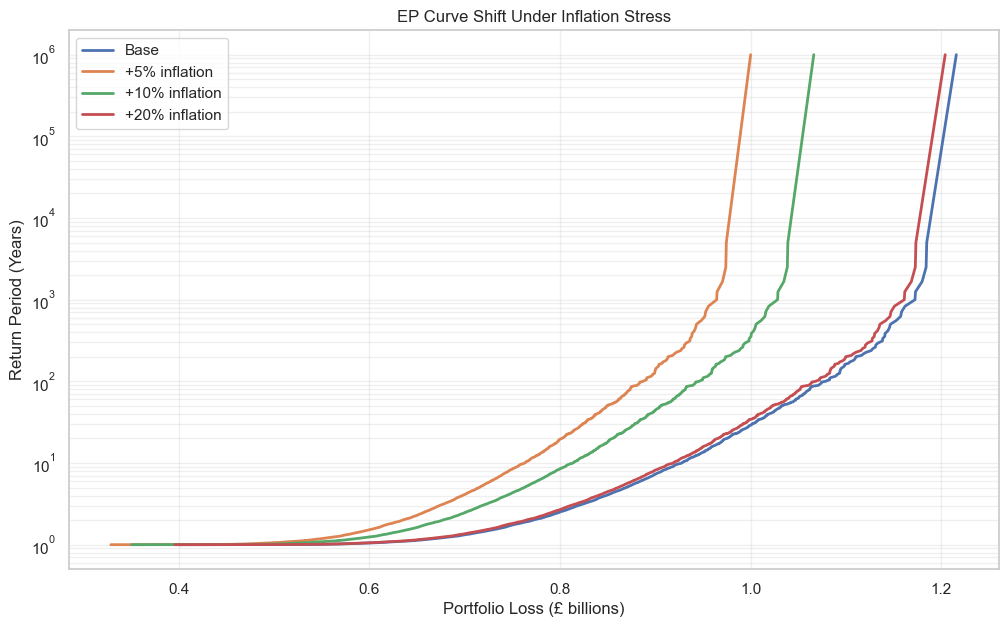

In [28]:
plt.figure(figsize=(12, 7))

base_sorted = np.sort(loss_distribution["portfolio_loss"].values)
n = len(base_sorted)
return_period = 1 / np.maximum(1 - (np.arange(1, n + 1) / n), 1e-6)

plt.plot(base_sorted / 1e9, return_period, label="Base", linewidth=2)

for shock in [0.05, 0.10, 0.20]:
    scale_factor = macro_results_df.loc[
        macro_results_df["inflation_shock"] == shock, "scale_factor"
    ].iloc[0]

    shifted = np.sort((loss_distribution["portfolio_loss"] * scale_factor).values)
    plt.plot(shifted / 1e9, return_period, label=f"+{int(shock*100)}% inflation", linewidth=2)

plt.yscale("log")
plt.xlabel("Portfolio Loss (£ billions)")
plt.ylabel("Return Period (Years)")
plt.title("EP Curve Shift Under Inflation Stress")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [29]:
fig = go.Figure()

# ---------------------------
# BAR: Tail risk (P99.5)
# ---------------------------
fig.add_trace(go.Bar(
    x=(macro_results_df["inflation_shock"] * 100).astype(int).astype(str) + "%",
    y=macro_results_df["p995_loss"] / 1e9,
    name="P99.5 Loss (SCR proxy)",
))

# ---------------------------
# LINE: Solvency ratio
# ---------------------------
fig.add_trace(go.Scatter(
    x=(macro_results_df["inflation_shock"] * 100).astype(int).astype(str) + "%",
    y=macro_results_df["solvency_ratio"],
    mode="lines+markers+text",
    text=[f"{v:.3f}" for v in macro_results_df["solvency_ratio"]],
    textposition="top center",
    name="Solvency Ratio",
    yaxis="y2"
))

# ---------------------------
# LAYOUT (CRITICAL FIXES)
# ---------------------------
fig.update_layout(
    title="Macro Stress Impact on Capital Adequacy (Solvency II View)",
    xaxis_title="Inflation Shock",

    # LEFT AXIS (CAPITAL / SCR)
    yaxis=dict(
        title="P99.5 Loss (£bn) — Solvency Capital Requirement (SCR proxy)",
    ),

    # RIGHT AXIS (SOLVENCY)
    yaxis2=dict(
        title="Solvency Ratio (Eligible Capital / SCR)",
        overlaying="y",
        side="right",
        range=[0, 2.5]   # 🔥 FIXED SCALE
    ),

    height=550,
)

# ---------------------------
# REGULATORY ZONES
# ---------------------------
fig.add_hline(
    y=1.0,
    line_dash="dash",
    annotation_text="Regulatory Minimum (SCR = 1.0)",
    annotation_position="top left",
    yref="y2"
)

fig.add_hline(
    y=1.5,
    line_dash="dot",
    annotation_text="Comfort Zone (≥1.5)",
    annotation_position="top left",
    yref="y2"
)

# ---------------------------
# OPTIONAL: DISTRESS ANNOTATION
# ---------------------------
min_sol = macro_results_df["solvency_ratio"].min()

fig.add_annotation(
    x=0,
    y=min_sol,
    xref="paper",
    yref="y2",
    text="Severe Capital Deficiency",
    showarrow=True,
    arrowhead=2
)

fig.show()

### Macro Stress Interpretation

This analysis shows how inflation stress propagates through the portfolio and into capital adequacy.

Key implications:

- rising inflation shifts the full EP curve to the right, not just expected loss
- tail risk deteriorates alongside central loss estimates
- solvency weakens as macro stress increases, indicating limited capital resilience
- motor business amplifies the macro effect because fraud-sensitive lines receive additional stress

This means macro deterioration is not only a pricing issue.
It is also a capital and solvency issue.

## Governance Status

In [30]:
governance, governance_ok

({'exposure_valid': True,
  'frequency_valid': True,
  'fraud_layer_present': True,
  'scenario_defined': True,
  'relativity_prod_missing': 0,
  'relativity_channel_missing': 0},
 True)

## Strategy Advisor

In [31]:
strategy_df.head(10)

,product_type,channel,action,recommended_rate_change_pct,retention_factor,metric_before,metric_after,capital_share_proxy,rationale
0,health,aggregator,Increase pricing aggressively,0.0800,0.9520,0.1308,0.1273,0.0433,Stressed loss ratio materially above portfolio...
1,motor,aggregator,Increase pricing moderately,0.0500,0.9400,0.1278,0.1295,0.0567,Stressed loss ratio above tolerance; Fraud-ove...
2,health,broker,Increase pricing moderately,0.0500,0.9700,0.1199,0.1178,0.1364,Stressed loss ratio above tolerance
3,health,direct,Increase pricing moderately,0.0500,0.9700,0.1176,0.1154,0.0761,Stressed loss ratio above tolerance
4,motor,broker,Increase pricing moderately,0.0500,0.9400,0.1164,0.1180,0.1891,Stressed loss ratio above tolerance; Fraud-ove...
5,home,aggregator,Increase pricing moderately,0.0500,0.9600,0.1162,0.1153,0.0580,Stressed loss ratio above tolerance
6,motor,direct,Review pricing and underwriting,0.0300,0.9640,0.1121,0.1129,0.1005,Stressed loss ratio slightly elevated; Fraud-o...
7,home,broker,Review pricing and underwriting,0.0300,0.9760,0.1056,0.1050,0.1932,Stressed loss ratio slightly elevated
8,home,direct,Maintain current stance,0.0000,1.0000,0.1012,0.1012,0.1001,Stressed loss ratio within acceptable range
9,warranty,aggregator,Maintain current stance,0.0000,1.0000,0.0588,0.0588,0.0046,Stressed loss ratio within acceptable range


In [32]:
fig = px.scatter(
    strategy_df,
    x="metric_before",
    y="metric_after",
    size="capital_share_proxy",
    color="action",
    hover_data=["product_type", "channel", "rationale"],
    title=f"Strategy Advisor — {pressure_label} Before vs After"
)
fig.show()

## Executive AI Reasoning Layer

In [33]:
ranked_segments = rank_segments_for_decision(segment)
ranked_segments.head(10)

,product_type,channel,policies,earned_premium,expected_frequency,freq_stressed,stressed_loss,mean_severity,actual_claim_count,actual_incurred,actual_avg_severity,loss_share,capital_share_proxy,stressed_loss_bn,loss_ratio_stressed,pressure_metric,pressure_label,risk_score
0,home,broker,13213,"180,201,216.3235","1,037.8720","1,120.9017","19,028,693.2684","15,157.3546",9539,"144,586,005.3463","15,157.3546",0.1932,0.1932,0.0190,0.1056,0.1056,loss_ratio_stressed,0.9095
1,motor,broker,29666,"159,939,455.2652","4,004.2972","4,324.6409","18,623,698.1613","3,076.0106",36609,"112,609,673.4536","3,076.0106",0.1891,0.1891,0.0186,0.1164,0.1164,loss_ratio_stressed,0.7829
2,home,direct,7137,"97,421,933.9738",527.8363,570.0632,"9,857,391.3985","15,439.0649",4645,"71,714,456.6389","15,439.0649",0.1001,0.1001,0.0099,0.1012,0.1012,loss_ratio_stressed,0.7293
3,health,broker,7713,"112,051,389.3847","2,075.4291","2,241.4635","13,439,792.3007","5,353.5624",18648,"99,833,232.2821","5,353.5624",0.1364,0.1364,0.0134,0.1199,0.1199,loss_ratio_stressed,0.7291
4,home,aggregator,3628,"49,178,768.1448",308.3365,333.0035,"5,715,829.6932","15,325.4239",2866,"43,922,664.9012","15,325.4239",0.0580,0.0580,0.0057,0.1162,0.1162,loss_ratio_stressed,0.7034
5,health,direct,4365,"63,763,734.2802","1,105.1450","1,193.5566","7,496,590.5847","5,607.9320",10485,"58,799,166.7838","5,607.9320",0.0761,0.0761,0.0075,0.1176,0.1176,loss_ratio_stressed,0.6149
6,motor,direct,16368,"88,275,331.7588","2,079.0630","2,245.3880","9,895,145.0616","3,147.7681",19856,"62,502,083.6358","3,147.7681",0.1005,0.1005,0.0099,0.1121,0.1121,loss_ratio_stressed,0.6083
7,health,aggregator,2244,"32,576,756.3359",654.5567,706.9212,"4,262,456.9961","5,383.5774",5531,"29,776,566.4224","5,383.5774",0.0433,0.0433,0.0043,0.1308,0.1308,loss_ratio_stressed,0.5981
8,motor,aggregator,8124,"43,730,024.6014","1,188.2007","1,283.2567","5,587,894.1636","3,110.3309",11156,"34,698,851.2359","3,110.3309",0.0567,0.0567,0.0056,0.1278,0.1278,loss_ratio_stressed,0.5825
9,warranty,broker,9902,"28,807,572.2672","1,489.7905","1,608.9738","1,587,749.9944",881.0796,13798,"12,157,135.8014",881.0796,0.0161,0.0161,0.0016,0.0551,0.0551,loss_ratio_stressed,0.2302


In [34]:
fig = px.bar(
    ranked_segments.head(10),
    x="product_type",
    y="risk_score",
    color="channel",
    barmode="group",
    title="Executive Risk Ranking — Composite Risk Score",
    hover_data=["stressed_loss", "loss_share", "mean_severity", "pressure_metric"]
)
fig.show()

In [35]:
fig = px.sunburst(
    ranked_segments,
    path=["product_type", "channel"],
    values="stressed_loss",
    color="risk_score",
    color_continuous_scale="RdBu_r",
    title="Executive Portfolio Risk Sunburst"
)
fig.show()

In [36]:
risk_analysis = (
    f"Portfolio stress is concentrated in {segment.iloc[0]['product_type']} / {segment.iloc[0]['channel']}, "
    f"which is the highest-pressure segment by stressed loss. "
    f"Its stressed_loss is {segment.iloc[0]['stressed_loss'] / 1e6:,.1f} million and loss_share is {segment.iloc[0]['loss_share']:.4f}."
)

capital_analysis = (
    f"Mean portfolio loss is {ep_metrics['mean_loss_bn']:.4f} bn, "
    f"1-in-200 loss is {ep_metrics['loss_1_in_200_bn']:.4f} bn, "
    f"and TVaR 99 is {ep_metrics['tvar_99_bn']:.4f} bn. "
    f"Capital required is {capital_required:,.0f}, capital available is {capital_available:,.0f}, "
    f"and solvency_ratio is {solvency_ratio:.4f}."
)

def classify_capital_severity(solvency_ratio: float) -> str:
    if solvency_ratio < 0.5:
        return "critical capital deficiency"
    elif solvency_ratio < 1.0:
        return "material capital shortfall"
    elif solvency_ratio < 1.5:
        return "adequate but below target"
    else:
        return "strong capital position"


severity_label = classify_capital_severity(solvency_ratio)

board_summary = board_commentary_agent({
    "segment": segment.to_dict(orient="records"),
    "capital_metrics": {
        "capital_required": capital_required,
        "capital_available": capital_available,
        "solvency_ratio": solvency_ratio,
        "severity_label": severity_label   # 🔥 inject explicitly
    },
    "ep_metrics": ep_metrics,
})

print(board_summary)

The portfolio is concentrated in home / broker, which ranks highest under the composite risk framework. Tail risk remains elevated, with a 1-in-200 loss of 1.1104 bn. The portfolio exhibits a critical capital deficiency, with a solvency ratio of 0.0450. Immediate management action is required across pricing, underwriting discipline, and capital optimisation.


In [37]:
payload = build_payload(
    snapshot=snapshot,
    premium_basis=premium_basis,
    pressure_label=pressure_label,
    phase6_metrics=phase6_metrics,
    ep_metrics=ep_metrics,
    governance=governance,
    governance_ok=governance_ok,
    capital_required=capital_required,
    capital_available=capital_available,
    solvency_ratio=solvency_ratio,
    risk_analysis=risk_analysis,
    capital_analysis=capital_analysis,
    board_summary=board_summary,
    segment=segment,
    strategy_df=strategy_df,
)

payload_path = paths.ph9 / "phase9_exec_payload.json"
save_payload(payload, payload_path)

print("Payload saved:", payload_path)

Payload saved: v:\Himika\Project\insurance-digital-twin\notebooks\outputs\phase9\phase9_exec_payload.json


In [38]:
payload["macro_stress_results"] = macro_results_df.to_dict(orient="records")
save_payload(payload, payload_path)

## Retrieval-Augmented Intelligence

In [39]:
docs = build_rag_documents(
    phase6_metrics=phase6_metrics,
    ep_metrics=ep_metrics,
    governance=governance,
    scenario_summary=scenario_summary,
    phase8_exec_report=phase8_exec_report,
    segment=segment,
    strategy_df=strategy_df,
)

In [40]:
sample_q = "Is the portfolio adequately capitalised?"
matches = retrieve_context(sample_q, docs)

for m in matches:
    print(f"\n[{m['source']}]\n{m['text'][:1000]}")


[phase8_exec_report]

PHASE 8 — PORTFOLIO SCENARIO SUMMARY

Scenario:
- inflation_shock: 12.00%
- frequency_shock: 8.00%
- fraud_multiplier: 1.25

Expected loss (deterministic): 863,742,148

Monte Carlo:
- mean:  778,896,816
- p95:   975,096,839
- p99.5: 1,110,431,946

Capital proxy:
- required: 1,554,604,724
- available: 50,000,000
- solvency ratio: 0.03


[strategy_top10]
product_type    channel                          action  recommended_rate_change_pct  retention_factor  metric_before  metric_after  capital_share_proxy                                                           rationale
      health aggregator   Increase pricing aggressively                       0.0800            0.9520         0.1308        0.1273               0.0433            Stressed loss ratio materially above portfolio tolerance
       motor aggregator     Increase pricing moderately                       0.0500            0.9400         0.1278        0.1295               0.0567   Stressed loss ratio above

In [41]:
sample_questions = [
    "Is the portfolio adequately capitalised?",
    "Where should leadership focus first?",
    "What pricing action should we take?",
    "Is governance acceptable?",
]

for q in sample_questions:
    result = executive_decision_agent(q, payload)
    print("\nQUESTION:", q)
    print("DECISION:", result["decision"])
    print("REASONING:")
    for r in result["reasoning"]:
        print("-", r)
    print("EVIDENCE:", result["evidence"])


QUESTION: Is the portfolio adequately capitalised?
DECISION: Critical capital deficiency
REASONING:
- Question classified as capital adequacy
- Capital required = 1,110,431,946
- Capital available = 50,000,000
- Solvency ratio = 0.0450
EVIDENCE: {'capital_required': 1110431945.718766, 'capital_available': 50000000.0, 'solvency_ratio': 0.04502752302180549, 'loss_1_in_200_bn': 1.110431945718766, 'tvar_99_bn': 1.1222984829990243}

QUESTION: Where should leadership focus first?
DECISION: Focus on home / broker
REASONING:
- Question classified as risk prioritisation
- Segments ranked using composite risk score
- Top ranked segment = home / broker
EVIDENCE: {'product_type': 'home', 'channel': 'broker', 'policies': 13213, 'earned_premium': 180201216.32350153, 'expected_frequency': 1037.8719558558762, 'freq_stressed': 1120.9017123243464, 'stressed_loss': 19028693.268403534, 'mean_severity': 15157.354580805111, 'actual_claim_count': 9539, 'actual_incurred': 144586005.34629995, 'actual_avg_seve

## Conclusion

Phase 9 converts prior actuarial, fraud, and capital layers into executive decision support.

The final platform now provides:
- portfolio stress concentration
- capital and tail-risk interpretation
- governance-aware commentary
- deterministic strategy actions
- executive AI decisions
- retrieval-assisted portfolio Q&A
- a stable export payload for the Streamlit cockpit

This is no longer just modelling.
It is portfolio decision intelligence.